# **BỘ DỮ LIỆU price_petroleum.xlsx**


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Đọc file
price = pd.read_excel("/content/drive/MyDrive/DACS_2/data/price_petroleum .xlsx")

# Xóa khoảng trắng thừa trong tên cột
price.columns = price.columns.str.strip()

# Xóa các cột Unnamed/rỗng
price = price.loc[:, ~price.columns.str.contains("^Unnamed")]

# Đổi tên cột ngày
price = price.rename(columns={"Ngày": "Date"})

print(price.shape)
display(price.head())
price.info()

(4595, 12)


,Date,MG97,MG95,MG92,NAPHTHA,KERO,DO 0.001%,DO 0.05%,FO 180,BRT DTD,BRT KH,WTI
0,Đơn vị tính,USD/bbl,USD/bbl,USD/bbl,USD/bbl,USD/bbl,USD/bbl,USD/bbl,USD/MT,USD/bbl,USD/bbl,USD/bbl
1,2008-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.345,109.13,112.53
2,2008-05-02 00:00:00,117.71,115.1,114.37,102.97,137.52,NaN,141.14,559.09,111.895,113.73,116.33
3,2008-05-05 00:00:00,122.72,120.11,119.39,106.65,140.58,NaN,144.12,576.81,116.5,117.59,119.98
4,2008-05-06 00:00:00,126.25,123.69,123.02,109.3,143.43,NaN,147.23,589.13,119.625,120.46,121.855


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4595 entries, 0 to 4594
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       4595 non-null   object
 1   MG97       4463 non-null   object
 2   MG95       4465 non-null   object
 3   MG92       4465 non-null   object
 4   NAPHTHA    4463 non-null   object
 5   KERO       4463 non-null   object
 6   DO 0.001%  4337 non-null   object
 7   DO 0.05%   4465 non-null   object
 8   FO 180     4463 non-null   object
 9   BRT DTD    4498 non-null   object
 10  BRT KH     4498 non-null   object
 11  WTI        4454 non-null   object
dtypes: object(12)
memory usage: 430.9+ KB


In [23]:
price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4595 entries, 0 to 4594
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       4595 non-null   object
 1   MG97       4463 non-null   object
 2   MG95       4465 non-null   object
 3   MG92       4465 non-null   object
 4   NAPHTHA    4463 non-null   object
 5   KERO       4463 non-null   object
 6   DO 0.001%  4337 non-null   object
 7   DO 0.05%   4465 non-null   object
 8   FO 180     4463 non-null   object
 9   BRT DTD    4498 non-null   object
 10  BRT KH     4498 non-null   object
 11  WTI        4454 non-null   object
dtypes: object(12)
memory usage: 430.9+ KB


In [24]:
#Bỏ dòng đơn vị tính
price = price[price["Date"] != "Đơn vị tính"].copy()

In [25]:
#Chuẩn hóa ngày và kiểu dữ liệu
# Chuyển Date về dạng ngày
price["Date"] = pd.to_datetime(price["Date"], errors="coerce")

# Bỏ dòng không có ngày hợp lệ
price = price.dropna(subset=["Date"])

# Sắp xếp theo thời gian
price = price.sort_values("Date").reset_index(drop=True)

# Chuyển các cột giá sang dạng số
price_cols = [col for col in price.columns if col != "Date"]

for col in price_cols:
    price[col] = pd.to_numeric(price[col], errors="coerce")

print(price.info())
print(price.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4594 entries, 0 to 4593
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4594 non-null   datetime64[ns]
 1   MG97       4462 non-null   float64       
 2   MG95       4464 non-null   float64       
 3   MG92       4464 non-null   float64       
 4   NAPHTHA    4462 non-null   float64       
 5   KERO       4462 non-null   float64       
 6   DO 0.001%  4336 non-null   float64       
 7   DO 0.05%   4464 non-null   float64       
 8   FO 180     4462 non-null   float64       
 9   BRT DTD    4497 non-null   float64       
 10  BRT KH     4497 non-null   float64       
 11  WTI        4453 non-null   float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 430.8 KB
None
        Date    MG97    MG95    MG92  NAPHTHA    KERO  DO 0.001%  DO 0.05%  \
0 2008-05-01     NaN     NaN     NaN      NaN     NaN        NaN       NaN   
1 2008-05-02

Kiểm tra thứ 7, Chủ nhật

In [26]:
price["DayOfWeek"] = price["Date"].dt.dayofweek
# 0 = Thứ 2, 6 = Chủ nhật

weekend_rows = price[price["DayOfWeek"] >= 5]

print("Số dòng rơi vào thứ 7, Chủ nhật:", weekend_rows.shape[0])
display(weekend_rows.head())

Số dòng rơi vào thứ 7, Chủ nhật: 0


,Date,MG97,MG95,MG92,NAPHTHA,KERO,DO 0.001%,DO 0.05%,FO 180,BRT DTD,BRT KH,WTI,DayOfWeek


In [27]:
price = price[price["DayOfWeek"] < 5].copy()

Kiểm tra ngày trùng lặp


In [28]:
duplicate_dates = price[price["Date"].duplicated(keep=False)]

print("Số dòng ngày trùng:", duplicate_dates.shape[0])
display(duplicate_dates)

Số dòng ngày trùng: 2


,Date,MG97,MG95,MG92,NAPHTHA,KERO,DO 0.001%,DO 0.05%,FO 180,BRT DTD,BRT KH,WTI,DayOfWeek
4379,2025-04-25,79.45,78.45,76.62,63.12,81.8,82.61,81.23,439.02,67.495,66.64,63.02,4
4380,2025-04-25,79.45,78.45,76.62,63.12,81.8,82.61,81.23,439.02,67.495,66.64,63.02,4


In [29]:
# Xóa ngày trùng, giữ dòng đầu tiên
price = price.drop_duplicates(subset=["Date"], keep="first").reset_index(drop=True)

print("Số dòng sau khi xóa ngày trùng:", price.shape[0])

# Kiểm tra lại
print("Số ngày còn trùng:", price["Date"].duplicated().sum())

Số dòng sau khi xóa ngày trùng: 4593
Số ngày còn trùng: 0


Kiểm tra dữ liệu thiếu

In [30]:
print("Số dòng thiếu MG95:", price["MG95"].isna().sum())

missing_mg95 = price[price["MG95"].isna()]
display(missing_mg95[["Date", "MG95"]].head())

Số dòng thiếu MG95: 130


,Date,MG95
0,2008-05-01,NaN
12,2008-05-19,NaN
109,2008-10-01,NaN
127,2008-10-27,NaN
157,2008-12-08,NaN


In [31]:
price_mg95 = price.dropna(subset=["MG95"]).copy()
price_mg95 = price_mg95.reset_index(drop=True)

print("Số dòng sau khi bỏ thiếu MG95:", price_mg95.shape[0])

Số dòng sau khi bỏ thiếu MG95: 4463


Kiểm tra dữ liệu thiếu toàn bộ biến

In [32]:
missing_table = pd.DataFrame({
    "missing_count": price.isna().sum(),
    "missing_percent": price.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_table)

,missing_count,missing_percent
DO 0.001%,258,5.617244
WTI,141,3.069889
FO 180,132,2.873939
NAPHTHA,132,2.873939
MG97,132,2.873939
KERO,132,2.873939
DO 0.05%,130,2.830394
MG95,130,2.830394
MG92,130,2.830394
BRT KH,97,2.111909


In [33]:
print("Số dòng thiếu MG95:", price["MG95"].isna().sum())

display(price[price["MG95"].isna()][["Date", "MG95"]].head())

Số dòng thiếu MG95: 130


,Date,MG95
0,2008-05-01,NaN
12,2008-05-19,NaN
109,2008-10-01,NaN
127,2008-10-27,NaN
157,2008-12-08,NaN


In [34]:
price = price.dropna(subset=["MG95"]).copy()
price = price.reset_index(drop=True)

Trực Quan Hoá

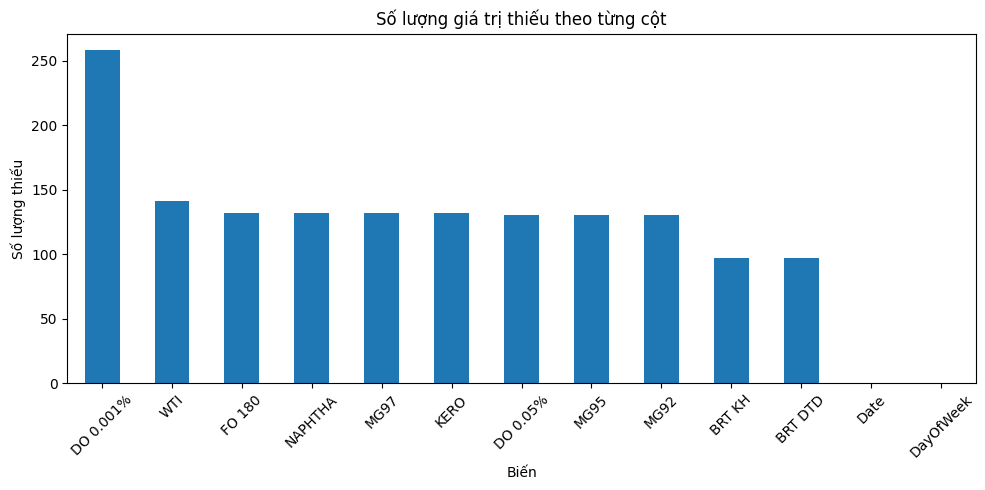

In [35]:
plt.figure(figsize=(10, 5))
missing_table["missing_count"].plot(kind="bar")

plt.title("Số lượng giá trị thiếu theo từng cột")
plt.xlabel("Biến")
plt.ylabel("Số lượng thiếu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

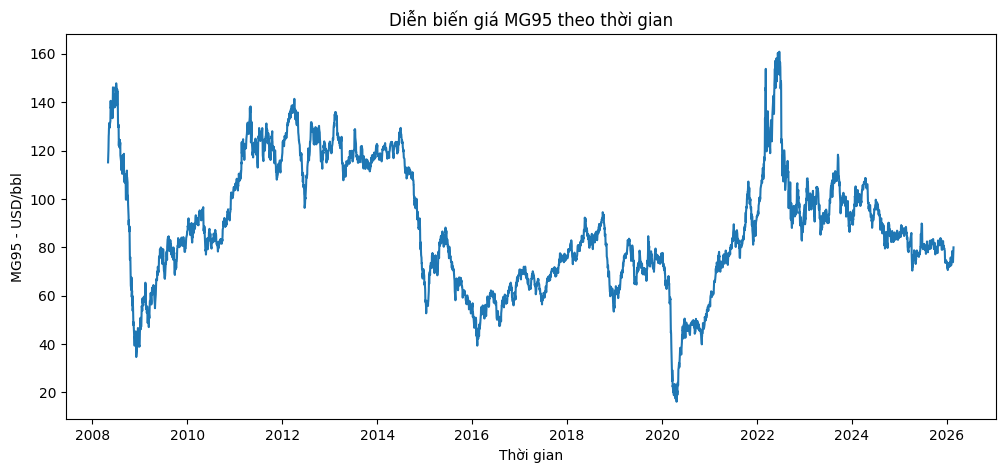

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(price["Date"], price["MG95"])

plt.title("Diễn biến giá MG95 theo thời gian")
plt.xlabel("Thời gian")
plt.ylabel("MG95 - USD/bbl")

plt.show()

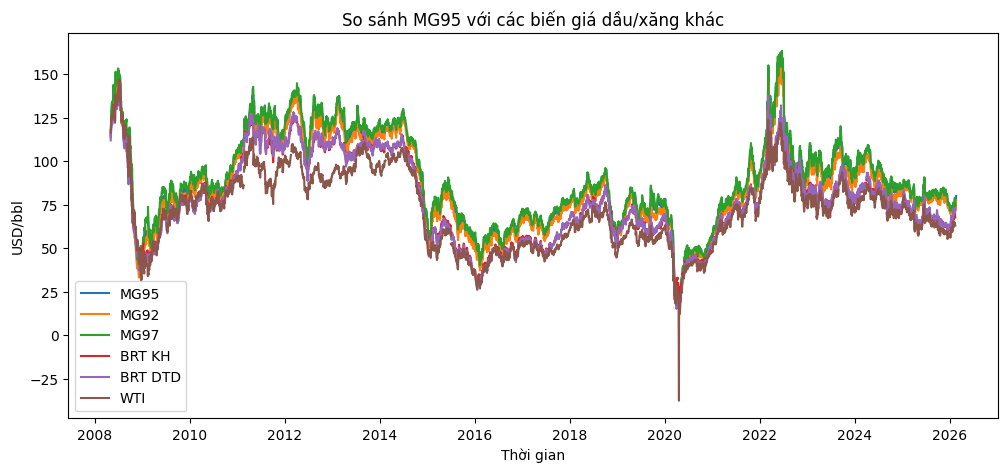

In [37]:
compare_cols = ["MG95", "MG92", "MG97", "BRT KH", "BRT DTD", "WTI"]

plt.figure(figsize=(12, 5))

for col in compare_cols:
    if col in price.columns:
        plt.plot(price["Date"], price[col], label=col)

plt.title("So sánh MG95 với các biến giá dầu/xăng khác")
plt.xlabel("Thời gian")
plt.ylabel("USD/bbl")
plt.legend()
plt.show()

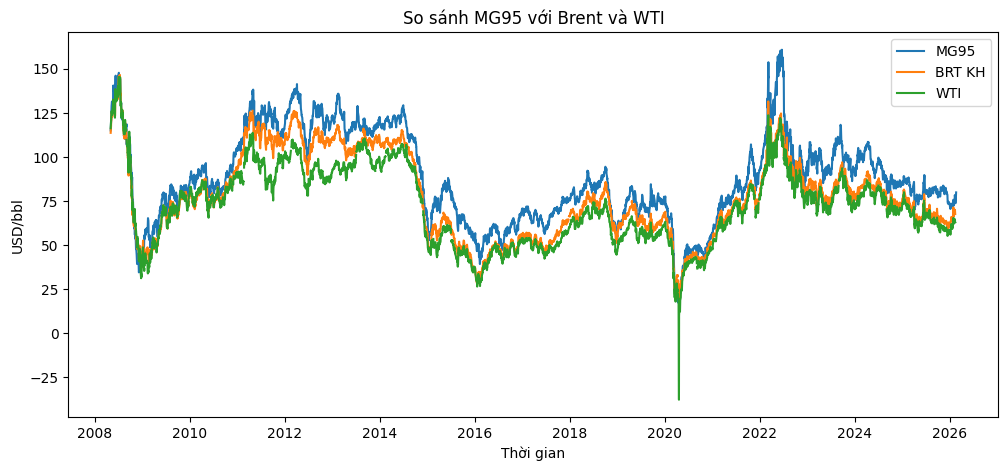

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(price["Date"], price["MG95"], label="MG95")
plt.plot(price["Date"], price["BRT KH"], label="BRT KH")
plt.plot(price["Date"], price["WTI"], label="WTI")

plt.title("So sánh MG95 với Brent và WTI")
plt.xlabel("Thời gian")
plt.ylabel("USD/bbl")
plt.legend()
plt.show()

Trực quan hoá biểu đồ ACF/PACF cho MG95

<Figure size 1200x500 with 0 Axes>

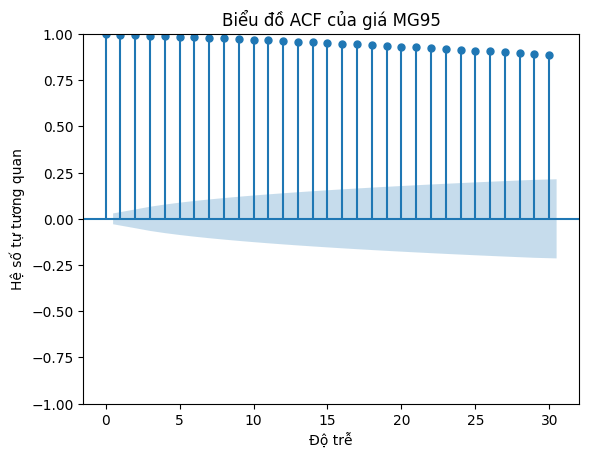

<Figure size 1200x500 with 0 Axes>

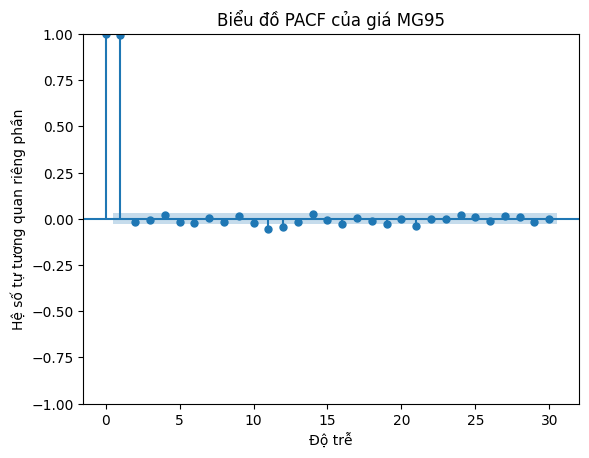

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

mg95_series = price["MG95"].dropna()

# ACF
plt.figure(figsize=(12, 5))
plot_acf(mg95_series, lags=30)
plt.title("Biểu đồ ACF của giá MG95")
plt.xlabel("Độ trễ")
plt.ylabel("Hệ số tự tương quan")
plt.show()

# PACF
plt.figure(figsize=(12, 5))
plot_pacf(mg95_series, lags=30, method="ywm")
plt.title("Biểu đồ PACF của giá MG95")
plt.xlabel("Độ trễ")
plt.ylabel("Hệ số tự tương quan riêng phần")
plt.show()

Trực quan hoá với MG95

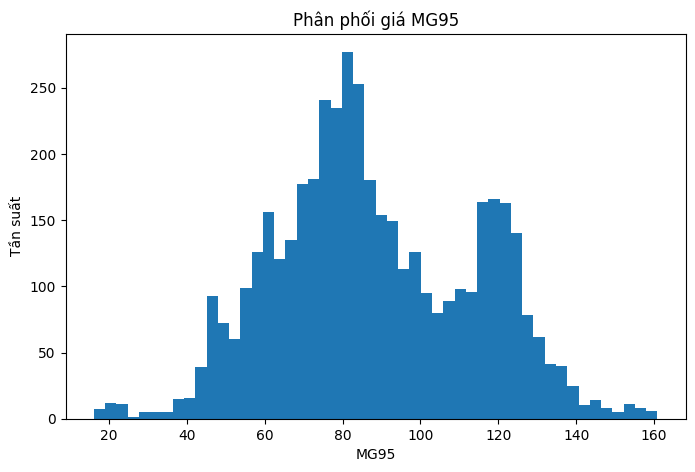

In [40]:
plt.figure(figsize=(8, 5))
plt.hist(price["MG95"].dropna(), bins=50)

plt.title("Phân phối giá MG95")
plt.xlabel("MG95")
plt.ylabel("Tần suất")
plt.show()

Ma trận tương quan giữa MG95 và các biến giá gốc

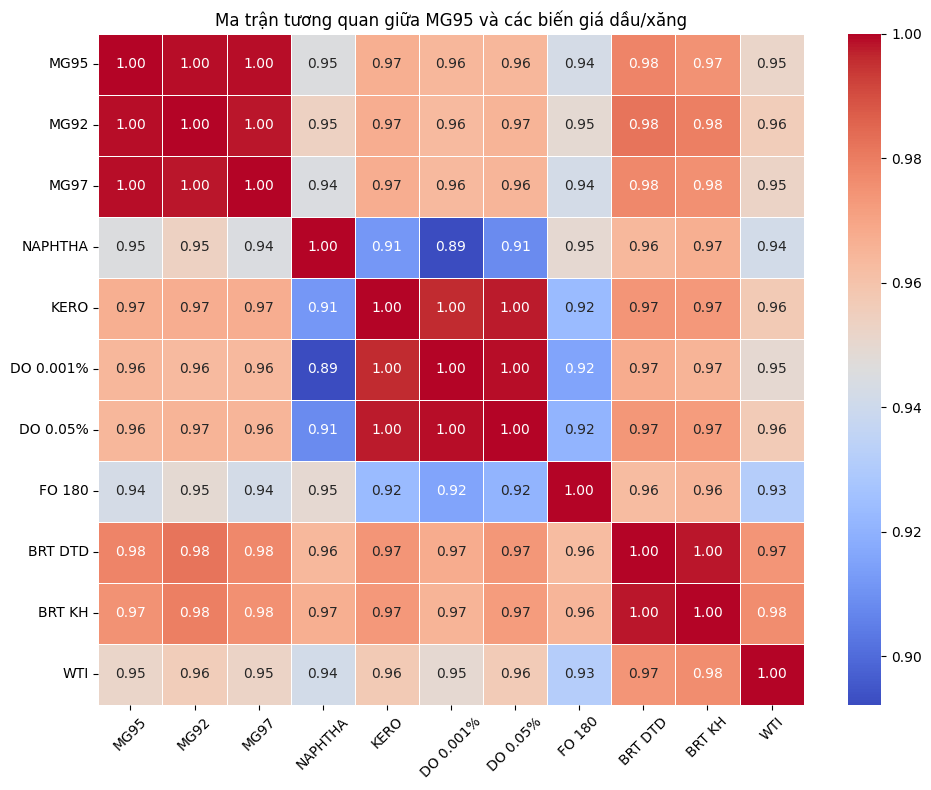

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "MG95", "MG92", "MG97", "NAPHTHA", "KERO",
    "DO 0.001%", "DO 0.05%", "FO 180",
    "BRT DTD", "BRT KH", "WTI"
]

corr_cols = [col for col in corr_cols if col in price.columns]

corr = price[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Ma trận tương quan giữa MG95 và các biến giá dầu/xăng")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

LƯU FILE

In [43]:
price_clean_cols = [
    "Date",
    "MG95",
    "MG92",
    "MG97",
    "NAPHTHA",
    "KERO",
    "DO 0.001%",
    "DO 0.05%",
    "FO 180",
    "BRT DTD",
    "BRT KH",
    "WTI"
]

price_clean = price[price_clean_cols].copy()

price_clean.to_csv(
    "price_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print(price_clean.shape)
display(price_clean.head())
price_clean.info()

(4463, 12)


,Date,MG95,MG92,MG97,NAPHTHA,KERO,DO 0.001%,DO 0.05%,FO 180,BRT DTD,BRT KH,WTI
0,2008-05-02,115.10,114.37,117.71,102.97,137.52,NaN,141.14,559.09,111.895,113.73,116.330
1,2008-05-05,120.11,119.39,122.72,106.65,140.58,NaN,144.12,576.81,116.500,117.59,119.980
2,2008-05-06,123.69,123.02,126.25,109.30,143.43,NaN,147.23,589.13,119.625,120.46,121.855
3,2008-05-07,126.02,125.40,128.54,109.30,144.51,NaN,148.00,593.83,119.525,120.58,123.545
4,2008-05-08,126.92,126.30,129.44,109.39,148.79,NaN,151.19,595.44,119.620,121.28,123.710


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4463 non-null   datetime64[ns]
 1   MG95       4463 non-null   float64       
 2   MG92       4463 non-null   float64       
 3   MG97       4461 non-null   float64       
 4   NAPHTHA    4461 non-null   float64       
 5   KERO       4461 non-null   float64       
 6   DO 0.001%  4335 non-null   float64       
 7   DO 0.05%   4463 non-null   float64       
 8   FO 180     4461 non-null   float64       
 9   BRT DTD    4376 non-null   float64       
 10  BRT KH     4376 non-null   float64       
 11  WTI        4326 non-null   float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 418.5 KB
